In [20]:
import pandas as pd

df = pd.read_csv("../data/amazon_reviews.csv")
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,d038997a-8c95-41d7-8b89-d23b8a0b1d3b,Sally “Turbogirl” King,I downloaded the app to resolve problems with ...,1,0,NaN,27-02-2026 09:23,NaN
1,d741afe7-dd35-4933-a637-6f5be41b225b,Evian Philippe,Having to use a browser to update the Prime me...,2,0,28.4.0.100,27-02-2026 08:53,28.4.0.100
2,33664e57-cc85-493f-b27b-fc247f6f028a,Satya Chaitanya,if Amazon becomes more involved with AI custom...,1,0,NaN,27-02-2026 08:17,NaN
3,b984cc39-b3e1-4687-a82d-5a29df880f4c,Lili Cardenas,STOP AUTOMATICALLY MAKING ME SUBSCRIBE FOR THI...,1,0,22.2.0.100,27-02-2026 08:03,22.2.0.100
4,6b0c027d-674a-4abf-a9f6-067b2c6d7790,Hanserd Douglas,good,5,0,NaN,27-02-2026 07:48,NaN


In [21]:
df.columns


Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='object')

In [22]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()

,reviewid,username,content,score,thumbsupcount,reviewcreatedversion,at,appversion
0,d038997a-8c95-41d7-8b89-d23b8a0b1d3b,Sally “Turbogirl” King,I downloaded the app to resolve problems with ...,1,0,NaN,27-02-2026 09:23,NaN
1,d741afe7-dd35-4933-a637-6f5be41b225b,Evian Philippe,Having to use a browser to update the Prime me...,2,0,28.4.0.100,27-02-2026 08:53,28.4.0.100
2,33664e57-cc85-493f-b27b-fc247f6f028a,Satya Chaitanya,if Amazon becomes more involved with AI custom...,1,0,NaN,27-02-2026 08:17,NaN
3,b984cc39-b3e1-4687-a82d-5a29df880f4c,Lili Cardenas,STOP AUTOMATICALLY MAKING ME SUBSCRIBE FOR THI...,1,0,22.2.0.100,27-02-2026 08:03,22.2.0.100
4,6b0c027d-674a-4abf-a9f6-067b2c6d7790,Hanserd Douglas,good,5,0,NaN,27-02-2026 07:48,NaN


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84926 entries, 0 to 84925
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewid              84926 non-null  object
 1   username              84920 non-null  object
 2   content               84920 non-null  object
 3   score                 84926 non-null  int64 
 4   thumbsupcount         84926 non-null  int64 
 5   reviewcreatedversion  75169 non-null  object
 6   at                    84926 non-null  object
 7   appversion            75169 non-null  object
dtypes: int64(2), object(6)
memory usage: 5.2+ MB


In [24]:
df.isnull().sum()


reviewid                   0
username                   6
content                    6
score                      0
thumbsupcount              0
reviewcreatedversion    9757
at                         0
appversion              9757
dtype: int64

In [25]:
df['at'] = pd.to_datetime(df['at'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84926 entries, 0 to 84925
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewid              84926 non-null  object        
 1   username              84920 non-null  object        
 2   content               84920 non-null  object        
 3   score                 84926 non-null  int64         
 4   thumbsupcount         84926 non-null  int64         
 5   reviewcreatedversion  75169 non-null  object        
 6   at                    84926 non-null  datetime64[ns]
 7   appversion            75169 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 5.2+ MB


C:\Users\hp\AppData\Local\Temp\ipykernel_10828\3673641237.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['at'] = pd.to_datetime(df['at'], errors='coerce')


In [26]:
df = df.dropna(subset=['content'])

In [27]:
df = df.dropna(subset=['score'])

In [28]:
df['thumbsupcount'] = df['thumbsupcount'].fillna(0)

In [29]:
df['username'] = df['username'].fillna("anonymous")

In [30]:
df = df.dropna(subset=['at'])

In [31]:
df.isnull().sum()

reviewid                   0
username                   0
content                    0
score                      0
thumbsupcount              0
reviewcreatedversion    9754
at                         0
appversion              9754
dtype: int64

In [32]:
df = df.drop(columns=['reviewcreatedversion', 'appversion'])

In [33]:
df.isnull().sum()


reviewid         0
username         0
content          0
score            0
thumbsupcount    0
at               0
dtype: int64

In [34]:
df['review_length'] = df['content'].astype(str).apply(len)
df[['content', 'review_length']].head()

,content,review_length
0,I downloaded the app to resolve problems with ...,135
1,Having to use a browser to update the Prime me...,224
2,if Amazon becomes more involved with AI custom...,92
3,STOP AUTOMATICALLY MAKING ME SUBSCRIBE FOR THI...,378
4,good,4


In [35]:
df['word_count'] = df['content'].astype(str).apply(lambda x: len(x.split()))
df[['word_count']].head()

,word_count
0,25
1,38
2,16
3,67
4,1


In [36]:
df['rating_deviation'] = abs(df['score'] - df['score'].mean())
df[['score', 'rating_deviation']].head()

,score,rating_deviation
0,1,1.622621
1,2,0.622621
2,1,1.622621
3,1,1.622621
4,5,2.377379


In [37]:
user_review_count = df.groupby('username')['reviewid'].count()
df['reviews_per_user'] = df['username'].map(user_review_count)

df[['username', 'reviews_per_user']].head()

,username,reviews_per_user
0,Sally “Turbogirl” King,1
1,Evian Philippe,1
2,Satya Chaitanya,7
3,Lili Cardenas,2
4,Hanserd Douglas,1


In [38]:
df['helpful_ratio'] = df['thumbsupcount'] / (df['reviews_per_user'] + 1)
df[['thumbsupcount', 'helpful_ratio']].head()

,thumbsupcount,helpful_ratio
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,0,0.0


In [39]:
!pip install nltk


In [40]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1032)>


False

In [41]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['content'].apply(clean_text)

df[['content', 'clean_text']].head()

,content,clean_text
0,I downloaded the app to resolve problems with ...,downloaded app resolve problem account try acc...
1,Having to use a browser to update the Prime me...,use browser update prime membership ridiculous...
2,if Amazon becomes more involved with AI custom...,amazon becomes involved ai customer service dr...
3,STOP AUTOMATICALLY MAKING ME SUBSCRIBE FOR THI...,stop automatically making subscribe thing dont...
4,good,good


In [42]:
df['reviews_per_user'] = df['reviews_per_user'].fillna(1)

In [43]:
df['helpful_ratio'] = df['helpful_ratio'].fillna(0)

In [44]:
df = df.reset_index(drop=True)

In [45]:
df.isnull().sum()

reviewid            0
username            0
content             0
score               0
thumbsupcount       0
at                  0
review_length       0
word_count          0
rating_deviation    0
reviews_per_user    0
helpful_ratio       0
clean_text          0
dtype: int64

In [46]:
df = df.sort_values(by=['username', 'at'])

In [47]:
df['time_diff'] = df.groupby('username')['at'].diff().dt.total_seconds()

In [48]:
df['burst_flag'] = df['time_diff'].apply(lambda x: 1 if pd.notnull(x) and x < 300 else 0)

In [49]:
df['time_diff'] = df['time_diff'].fillna(999999)

In [50]:
df[['username','time_diff','burst_flag']].head(10)

,username,time_diff,burst_flag
57182,############,999999.0,0
14245,#441RACINGGARAGE,999999.0,0
61163,#Arman NeetAsp.,999999.0,0
83397,#NAME?,999999.0,0
29425,#NAME?,105069060.0,0
13792,#djRobertoLive,999999.0,0
6451,#shane Superstar,999999.0,0
14203,'G' Vincent,999999.0,0
64956,* Kemp,999999.0,0
50672,**,999999.0,0


In [51]:
df['burst_flag'].value_counts()

burst_flag
0    84033
1      887
Name: count, dtype: int64

In [52]:
df['extreme_rating'] = df['score'].apply(lambda x: 1 if x == 1 or x == 5 else 0)

In [53]:
df['short_review'] = df['word_count'].apply(lambda x: 1 if x < 5 else 0)

In [54]:
df['suspicion_score'] = (
    df['extreme_rating'] +
    df['short_review'] +
    df['burst_flag']
)

In [55]:
df['pseudo_label'] = df['suspicion_score'].apply(lambda x: 1 if x >= 2 else 0)

In [56]:
df['pseudo_label'].value_counts()

pseudo_label
0    75794
1     9126
Name: count, dtype: int64

In [57]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['pseudo_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (67936,)
Test size: (16984,)


In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (67936, 5000)


In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [60]:
y_pred = model.predict(X_test_tfidf)

In [61]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9380593499764485

Confusion Matrix:
 [[14847   312]
 [  740  1085]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97     15159
           1       0.78      0.59      0.67      1825

    accuracy                           0.94     16984
   macro avg       0.86      0.79      0.82     16984
weighted avg       0.93      0.94      0.93     16984



In [62]:
df.to_csv("final_processed_reviews.csv", index=False)

In [63]:
import pickle

# Save model
with open("text_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

In [64]:
import os
os.listdir()

['.ipynb_checkpoints',
 'fake_review_model.pkl',
 'final_processed_reviews.csv',
 'processed_reviews.csv',
 'project.ipynb',
 'text_model.pkl',
 'tfidf_vectorizer.pkl']

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

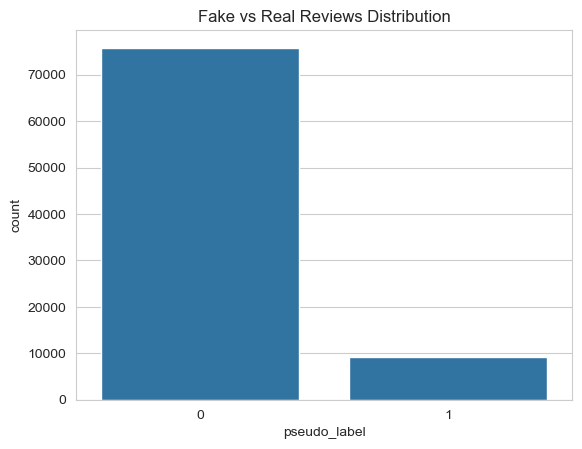

In [66]:
sns.countplot(x=df['pseudo_label'])
plt.title("Fake vs Real Reviews Distribution")
plt.show()

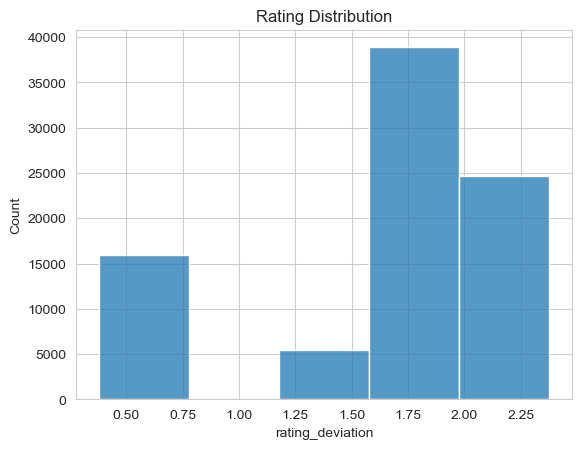

In [67]:
sns.histplot(df['rating_deviation'], bins=5)
plt.title("Rating Distribution")
plt.show()

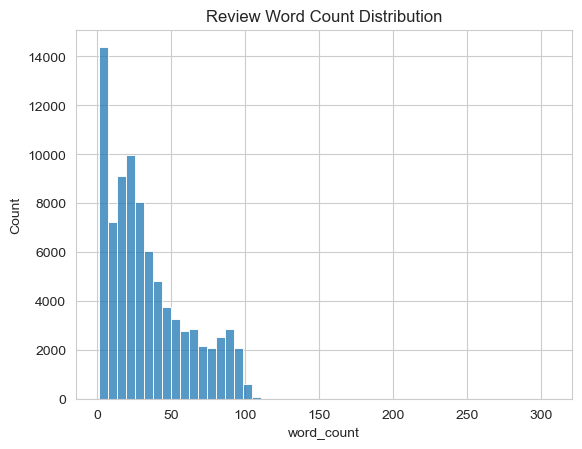

In [68]:
sns.histplot(df['word_count'], bins=50)
plt.title("Review Word Count Distribution")
plt.show()

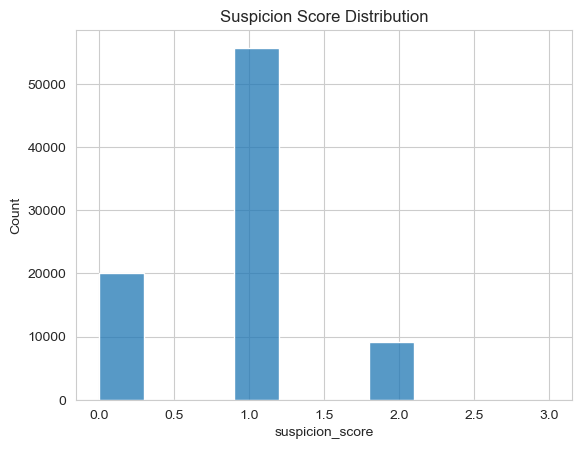

In [69]:
sns.histplot(df['suspicion_score'], bins=10)
plt.title("Suspicion Score Distribution")
plt.show()

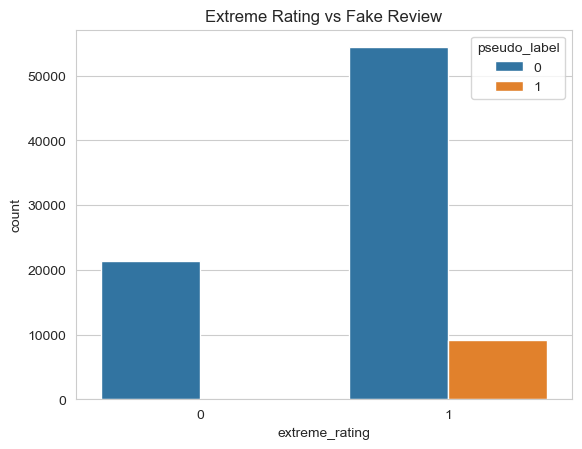

In [70]:
sns.countplot(x='extreme_rating', hue='pseudo_label', data=df)
plt.title("Extreme Rating vs Fake Review")
plt.show()

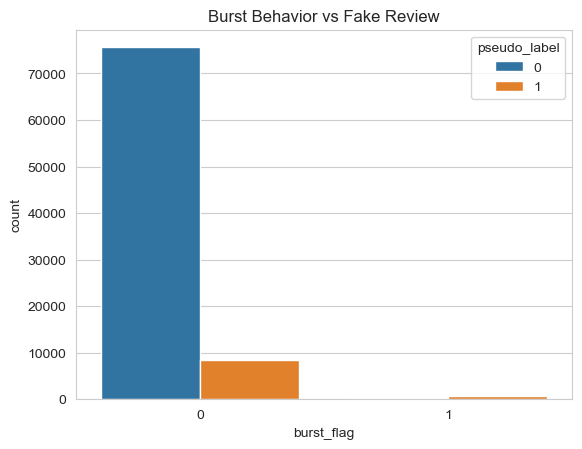

In [71]:
sns.countplot(x='burst_flag', hue='pseudo_label', data=df)
plt.title("Burst Behavior vs Fake Review")
plt.show()

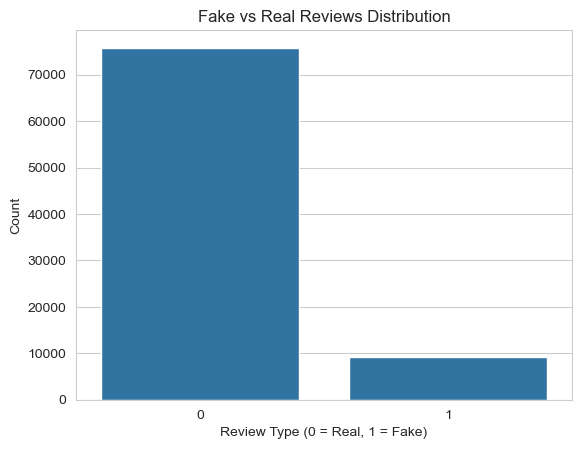

In [72]:
sns.countplot(x=df['pseudo_label'])
plt.title("Fake vs Real Reviews Distribution")
plt.xlabel("Review Type (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.show()

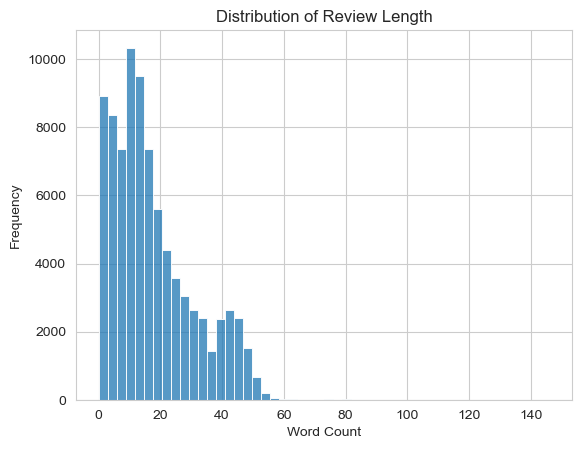

In [73]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

sns.histplot(df['word_count'], bins=50)
plt.title("Distribution of Review Length")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

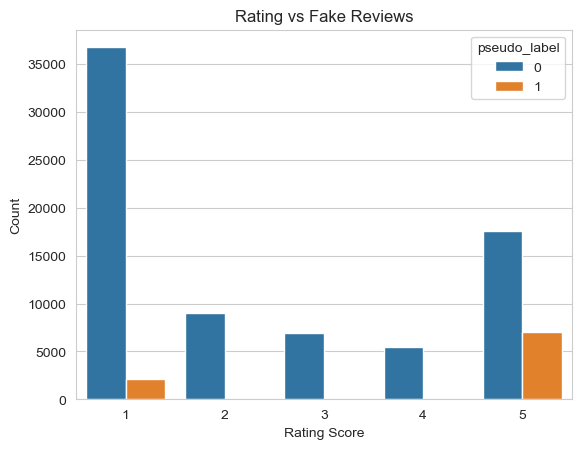

In [74]:
sns.countplot(x=df['score'], hue=df['pseudo_label'])
plt.title("Rating vs Fake Reviews")
plt.xlabel("Rating Score")
plt.ylabel("Count")
plt.show()

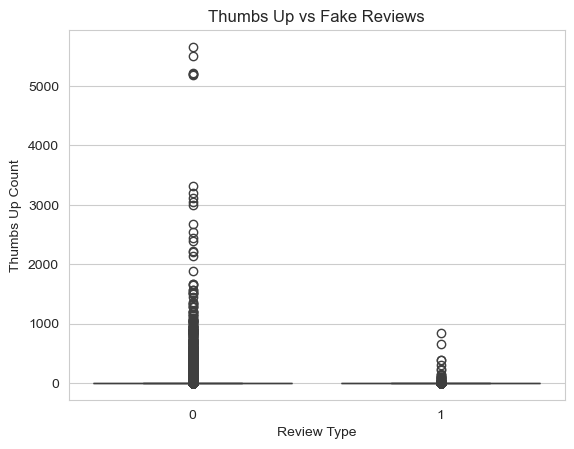

In [75]:
sns.boxplot(x=df['pseudo_label'], y=df['thumbsupcount'])
plt.title("Thumbs Up vs Fake Reviews")
plt.xlabel("Review Type")
plt.ylabel("Thumbs Up Count")
plt.show()

In [76]:
df.to_csv("final_processed_reviews.csv", index=False)

In [77]:
import os
os.listdir()

['.ipynb_checkpoints',
 'fake_review_model.pkl',
 'final_processed_reviews.csv',
 'processed_reviews.csv',
 'project.ipynb',
 'text_model.pkl',
 'tfidf_vectorizer.pkl']

In [78]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [79]:
df = pd.read_csv("final_processed_reviews.csv")

df.head()

,reviewid,username,content,score,thumbsupcount,at,review_length,word_count,rating_deviation,reviews_per_user,helpful_ratio,clean_text,time_diff,burst_flag,extreme_rating,short_review,suspicion_score,pseudo_label
0,892517fd-dab6-49ae-80df-78bb12d147cf,############,Your app is causing issues. Your prime account...,2,0,2023-08-21 12:42:00,273,28,0.622621,1,0.000000,app causing issue prime account also linked vi...,999999.0,0,0,0,0,0
1,fd438d55-566d-4063-8e2d-e4090c5ab9a9,#441RACINGGARAGE,The bigger amazon gets the more they suck and ...,1,0,2025-03-02 04:23:00,331,31,1.622621,1,0.000000,bigger amazon get suck less care customer prim...,999999.0,0,1,0,1,0
2,85bb578a-6f0d-493a-8f20-122c5a17e0dd,#Arman NeetAsp.,very bad experience on amazone pay they are ma...,1,1,2022-04-24 09:12:00,499,50,1.622621,1,0.500000,bad experience amazone pay making fool name ca...,999999.0,0,1,0,1,0
3,ac1a8ad4-807d-4bad-8718-0cb591b147f0,#NAME?,"Not transparent with subscriptions, only notic...",1,1,2021-03-13 07:35:00,165,13,1.622621,2,0.333333,transparent subscription noticed deduction mon...,999999.0,0,1,0,1,0
4,3a9b75c7-03d0-4678-8647-82093c8935d4,#NAME?,"How do I turn ""roofus"" artificial stupidity of...",1,1,2024-07-11 09:26:00,500,45,1.622621,2,0.333333,turn roofus artificial stupidity stop seeing d...,105069060.0,0,1,0,1,0


In [80]:
df['clean_text'] = df['clean_text'].fillna("")

In [81]:
X = df['clean_text']
y = df['pseudo_label']

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (67936,)
Test size: (16984,)


In [83]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(67936, 5000)


In [84]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [85]:
y_pred = model.predict(X_test_tfidf)

In [86]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9380593499764485

Confusion Matrix:
 [[14847   312]
 [  740  1085]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97     15159
           1       0.78      0.59      0.67      1825

    accuracy                           0.94     16984
   macro avg       0.86      0.79      0.82     16984
weighted avg       0.93      0.94      0.93     16984



In [87]:
import os
os.listdir()

['.ipynb_checkpoints',
 'fake_review_model.pkl',
 'final_processed_reviews.csv',
 'processed_reviews.csv',
 'project.ipynb',
 'text_model.pkl',
 'tfidf_vectorizer.pkl']

In [88]:
from sklearn.naive_bayes import MultinomialNB

In [89]:
nb_model = MultinomialNB()

In [90]:
nb_model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [91]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [92]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Accuracy: 0.9125647668393783

Confusion Matrix:
 [[15013   146]
 [ 1339   486]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95     15159
           1       0.77      0.27      0.40      1825

    accuracy                           0.91     16984
   macro avg       0.84      0.63      0.67     16984
weighted avg       0.90      0.91      0.89     16984



In [93]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

In [94]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.9380593499764485

Confusion Matrix:
 [[14847   312]
 [  740  1085]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97     15159
           1       0.78      0.59      0.67      1825

    accuracy                           0.94     16984
   macro avg       0.86      0.79      0.82     16984
weighted avg       0.93      0.94      0.93     16984



In [95]:
from sklearn.ensemble import RandomForestClassifier

In [96]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_tfidf, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
y_pred_rf = rf_model.predict(X_test_tfidf)

In [98]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.9488930758360811

Confusion Matrix:
 [[14744   415]
 [  453  1372]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     15159
           1       0.77      0.75      0.76      1825

    accuracy                           0.95     16984
   macro avg       0.87      0.86      0.87     16984
weighted avg       0.95      0.95      0.95     16984



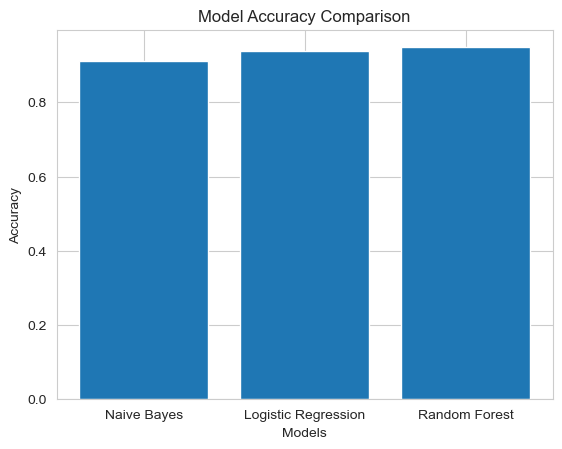

In [99]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'Logistic Regression', 'Random Forest']
accuracy = [0.912, 0.938, 0.948]

plt.figure()
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [100]:
!pip install wordcloud

In [101]:
import sys
!{sys.executable} -m pip install wordcloud

In [102]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

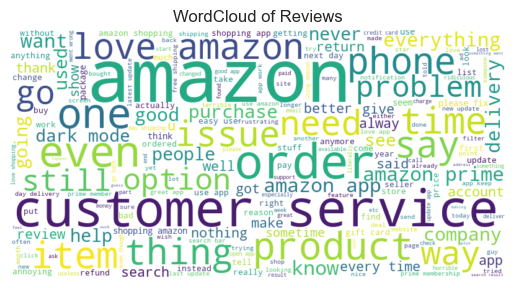

In [103]:
text = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud of Reviews")
plt.show()

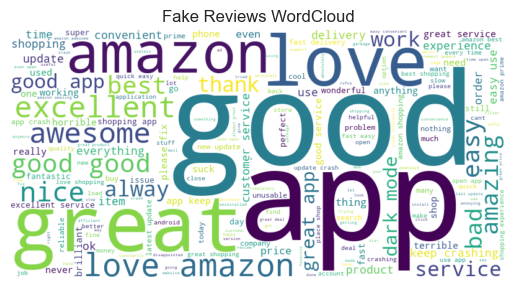

In [104]:
fake_reviews = " ".join(df[df['pseudo_label']==1]['clean_text'])

wordcloud_fake = WordCloud(width=800, height=400, background_color='white').generate(fake_reviews)

plt.figure()
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis("off")
plt.title("Fake Reviews WordCloud")
plt.show()

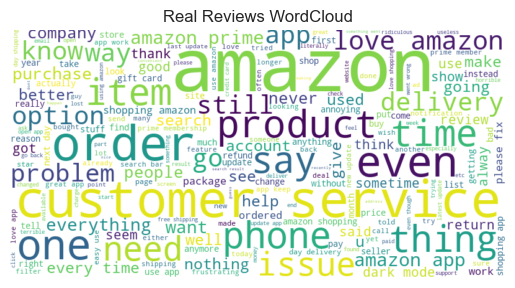

In [105]:
real_reviews = " ".join(df[df['pseudo_label']==0]['clean_text'])

wordcloud_real = WordCloud(width=800, height=400, background_color='white').generate(real_reviews)

plt.figure()
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis("off")
plt.title("Real Reviews WordCloud")
plt.show()

In [106]:
import re

def clean_review(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text


def predict_review(review):
    
    review = clean_review(review)
    
    review_tfidf = tfidf.transform([review])
    
    prediction = rf_model.predict(review_tfidf)
    
    if prediction[0] == 1:
        print("⚠️ Fake Review Detected")
    else:
        print("✅ Real Review")

In [107]:
predict_review("This product is amazing and works perfectly")

✅ Real Review


In [108]:
predict_review("Best product ever!!! Buy now!!! Highly recommended!!!!")

✅ Real Review


In [109]:
predict_review("Worst product ever waste of money")

✅ Real Review


In [110]:
predict_review("Excellent product highly recommended best purchase")

✅ Real Review


In [111]:
import numpy as np
np.unique(y_pred_rf, return_counts=True)

(array([0, 1]), array([15197,  1787]))

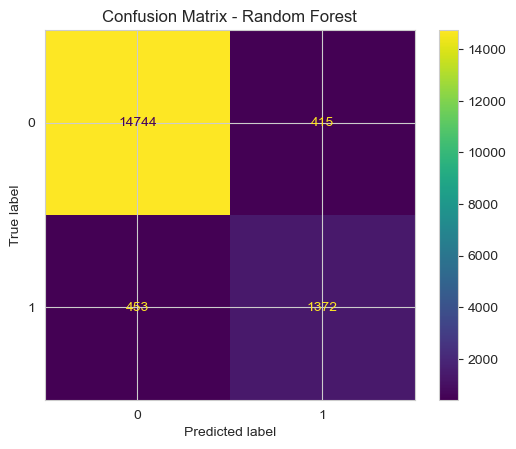

In [112]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [113]:
feature_names = tfidf.get_feature_names_out()

In [114]:
import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'word': feature_names,
    'importance': importance
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

feature_importance.head(20)

,word,importance
1890,good,0.048476
2584,love,0.043946
216,app,0.040811
1915,great,0.039703
164,amazon,0.039256
1515,excellent,0.016947
349,awesome,0.014306
1364,easy,0.013919
3928,service,0.013913
2992,order,0.012922


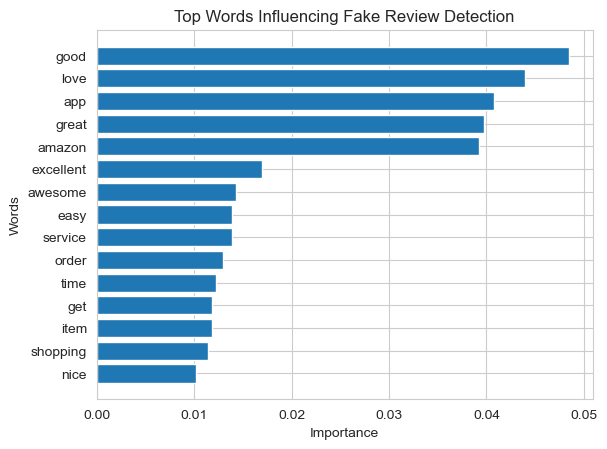

In [115]:
top_words = feature_importance.head(15)

import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_words['word'], top_words['importance'])

plt.xlabel("Importance")
plt.ylabel("Words")
plt.title("Top Words Influencing Fake Review Detection")

plt.gca().invert_yaxis()

plt.show()

In [116]:
import joblib

joblib.dump(rf_model, "fake_review_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [117]:
df.to_csv("processed_reviews.csv", index=False)

In [118]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [0.912, 0.938, 0.949]
})

results

,Model,Accuracy
0,Naive Bayes,0.912
1,Logistic Regression,0.938
2,Random Forest,0.949


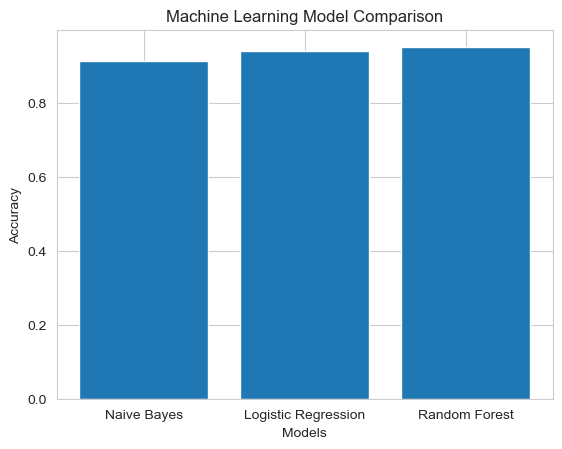

In [119]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(results['Model'], results['Accuracy'])

plt.title("Machine Learning Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [120]:
test_reviews = [
    "This product is amazing",
    "Worst app ever",
    "Excellent service highly recommended",
    "Terrible experience waste of money",
    "Good quality product"
]

for review in test_reviews:
    print("Review:", review)
    predict_review(review)
    print("-------------------")

Review: This product is amazing
⚠️ Fake Review Detected
-------------------
Review: Worst app ever
⚠️ Fake Review Detected
-------------------
Review: Excellent service highly recommended
✅ Real Review
-------------------
Review: Terrible experience waste of money
✅ Real Review
-------------------
Review: Good quality product
✅ Real Review
-------------------


In [121]:
def predict_review(review):
    review = clean_review(review)
    review_vec = tfidf.transform([review])

    pred = rf_model.predict(review_vec)[0]
    prob = rf_model.predict_proba(review_vec)[0]

    if pred == 1:
        print("⚠️ Fake Review")
    else:
        print("✅ Real Review")

    print("Fake probability:", round(prob[1],3))

In [122]:
predict_review("This product is amazing and works perfectly")

✅ Real Review
Fake probability: 0.3


In [123]:
predict_review("worst app ever")

⚠️ Fake Review
Fake probability: 0.972


In [124]:
predict_review("This app is useful")

✅ Real Review
Fake probability: 0.27


In [125]:
predict_review("very very bad experience")

⚠️ Fake Review
Fake probability: 0.659


In [126]:
predict_review("i am highly satisfied with the product")

✅ Real Review
Fake probability: 0.36


In [127]:
predict_review("This product is amazing and works good")

⚠️ Fake Review
Fake probability: 0.535


In [128]:
!pip install vaderSentiment

In [129]:
import sys
!{sys.executable} -m pip install vaderSentiment

In [130]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['clean_text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

In [131]:
def get_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['sentiment_score'].apply(get_sentiment)

In [132]:
df[['clean_text','sentiment_score','sentiment']].head()

,clean_text,sentiment_score,sentiment
0,app causing issue prime account also linked vi...,-0.6908,Negative
1,bigger amazon get suck less care customer prim...,0.0790,Positive
2,bad experience amazone pay making fool name ca...,-0.2969,Negative
3,transparent subscription noticed deduction mon...,-0.2500,Negative
4,turn roofus artificial stupidity stop seeing d...,-0.4019,Negative


In [133]:
df['sentiment'].value_counts()

sentiment
Positive    49053
Negative    25482
Neutral     10385
Name: count, dtype: int64

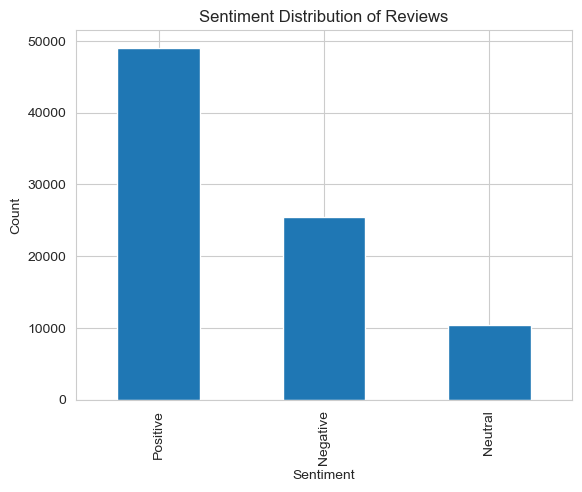

In [134]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution of Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [135]:
df.columns

Index(['reviewid', 'username', 'content', 'score', 'thumbsupcount', 'at',
       'review_length', 'word_count', 'rating_deviation', 'reviews_per_user',
       'helpful_ratio', 'clean_text', 'time_diff', 'burst_flag',
       'extreme_rating', 'short_review', 'suspicion_score', 'pseudo_label',
       'sentiment_score', 'sentiment'],
      dtype='object')

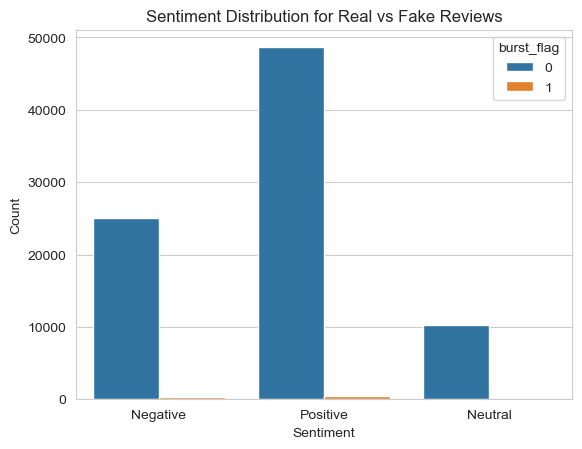

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.countplot(x='sentiment', hue='burst_flag', data=df)

plt.title("Sentiment Distribution for Real vs Fake Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

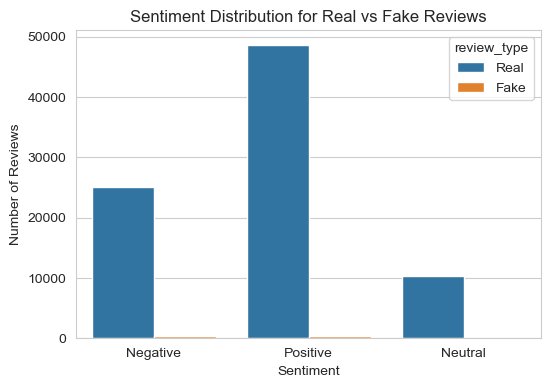

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt

# create readable labels
df['review_type'] = df['burst_flag'].map({0: 'Real', 1: 'Fake'})

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='sentiment', hue='review_type')

plt.title("Sentiment Distribution for Real vs Fake Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [138]:
test_reviews = [
    "This product is amazing and works good",
    "Worst product ever waste of money",
    "Excellent service highly recommended",
    "I love this product!!!",
    "Terrible experience not worth buying",
    "Good quality and fast delivery",
    
]

for review in test_reviews:
    print("Review:", review)
    predict_review(review)
    print("-----------------------")

Review: This product is amazing and works good
⚠️ Fake Review
Fake probability: 0.535
-----------------------
Review: Worst product ever waste of money
✅ Real Review
Fake probability: 0.03
-----------------------
Review: Excellent service highly recommended
✅ Real Review
Fake probability: 0.37
-----------------------
Review: I love this product!!!
⚠️ Fake Review
Fake probability: 0.941
-----------------------
Review: Terrible experience not worth buying
✅ Real Review
Fake probability: 0.359
-----------------------
Review: Good quality and fast delivery
✅ Real Review
Fake probability: 0.115
-----------------------


In [139]:
import joblib

joblib.dump(rf_model, "fake_review_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [140]:
df.to_csv("processed_reviews.csv", index=False)

In [141]:
model = joblib.load("fake_review_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")